# Trader Performance vs Market Sentiment Analysis

## Objective

The objective of this project is to analyze the relationship between Bitcoin market sentiment (Fear & Greed Index) and trader behavior on the Hyperliquid platform.

This analysis aims to answer the following questions:

- Does trader profitability change during Fear and Greed market conditions?
- Do traders alter their behavior (trade frequency, leverage, position size, long/short bias) based on market sentiment?
- Which trader segments perform best under different market conditions?
- What actionable trading strategies can be derived from the analysis?

The project combines the Bitcoin Fear & Greed Index dataset with historical Hyperliquid trading data to generate insights using Python and data visualization.

In [1]:
# Suppress warnings
import warnings
warnings.filterwarnings("ignore")

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning (optional for bonus)
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Plot style
plt.style.use("ggplot")

print("Libraries imported successfully!")

Matplotlib is building the font cache; this may take a moment.


Libraries imported successfully!


In [7]:
# Load datasets
fear = pd.read_csv("../data/fear_greed_index.csv")
trades = pd.read_csv("../data/historical_data.csv")

print("Fear & Greed Dataset Shape:", fear.shape)
print("Historical Trades Dataset Shape:", trades.shape)

Fear & Greed Dataset Shape: (2644, 4)
Historical Trades Dataset Shape: (211224, 16)


In [8]:
print("Fear & Greed Dataset")
display(fear.head())

print("\nHistorical Trader Dataset")
display(trades.head())

Fear & Greed Dataset


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05



Historical Trader Dataset


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [9]:
print("Fear & Greed Dataset Info")
fear.info()

print("\nHistorical Dataset Info")
trades.info()

Fear & Greed Dataset Info
<class 'pandas.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   timestamp       2644 non-null   int64
 1   value           2644 non-null   int64
 2   classification  2644 non-null   str  
 3   date            2644 non-null   str  
dtypes: int64(2), str(2)
memory usage: 82.8 KB

Historical Dataset Info
<class 'pandas.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  str    
 1   Coin              211224 non-null  str    
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  str    
 6   Timestamp IST     211224 non-null  str    
 7   Start Positi

In [10]:
fear.describe(include="all")

,timestamp,value,classification,date
count,2.644000e+03,2644.000000,2644,2644
unique,NaN,NaN,5,2644
top,NaN,NaN,Fear,2018-02-01
freq,NaN,NaN,781,1
mean,1.631899e+09,46.981089,NaN,NaN
std,6.597967e+07,21.827680,NaN,NaN
min,1.517463e+09,5.000000,NaN,NaN
25%,1.574811e+09,28.000000,NaN,NaN
50%,1.631900e+09,46.000000,NaN,NaN
75%,1.688989e+09,66.000000,NaN,NaN


In [12]:
trades.describe(include="all")

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
count,211224,211224,211224.000000,2.112240e+05,2.112240e+05,211224,211224,2.112240e+05,211224,211224.000000,211224,2.112240e+05,211224,211224.000000,2.112240e+05,2.112240e+05
unique,32,246,NaN,NaN,NaN,2,27977,NaN,12,NaN,101184,NaN,2,NaN,NaN,NaN
top,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,HYPE,NaN,NaN,NaN,SELL,14-02-2025 00:31,NaN,Open Long,NaN,0x00000000000000000000000000000000000000000000...,NaN,True,NaN,NaN,NaN
freq,40184,68005,NaN,NaN,NaN,108528,441,NaN,49895,NaN,9032,NaN,128403,NaN,NaN,NaN
mean,NaN,NaN,11414.723350,4.623365e+03,5.639451e+03,NaN,NaN,-2.994625e+04,NaN,48.749001,NaN,6.965388e+10,NaN,1.163967,5.628549e+14,1.737744e+12
std,NaN,NaN,29447.654868,1.042729e+05,3.657514e+04,NaN,NaN,6.738074e+05,NaN,919.164828,NaN,1.835753e+10,NaN,6.758854,3.257565e+14,8.689920e+09
min,NaN,NaN,0.000005,8.740000e-07,0.000000e+00,NaN,NaN,-1.433463e+07,NaN,-117990.104100,NaN,1.732711e+08,NaN,-1.175712,0.000000e+00,1.680000e+12
25%,NaN,NaN,4.854700,2.940000e+00,1.937900e+02,NaN,NaN,-3.762311e+02,NaN,0.000000,NaN,5.983853e+10,NaN,0.016121,2.810000e+14,1.740000e+12
50%,NaN,NaN,18.280000,3.200000e+01,5.970450e+02,NaN,NaN,8.472793e+01,NaN,0.000000,NaN,7.442939e+10,NaN,0.089578,5.620000e+14,1.740000e+12
75%,NaN,NaN,101.580000,1.879025e+02,2.058960e+03,NaN,NaN,9.337278e+03,NaN,5.792797,NaN,8.335543e+10,NaN,0.393811,8.460000e+14,1.740000e+12


In [13]:
missing_fear = fear.isnull().sum().sort_values(ascending=False)
missing_trades = trades.isnull().sum().sort_values(ascending=False)

print("Fear Dataset Missing Values")
display(missing_fear)

print("\nTrades Dataset Missing Values")
display(missing_trades)

Fear Dataset Missing Values


timestamp         0
value             0
classification    0
date              0
dtype: int64


Trades Dataset Missing Values


Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

In [14]:
print("Fear Dataset Duplicates:", fear.duplicated().sum())
print("Trades Dataset Duplicates:", trades.duplicated().sum())

Fear Dataset Duplicates: 0
Trades Dataset Duplicates: 0


In [15]:
print("Fear & Greed Columns")
print(fear.columns.tolist())

print("\nHistorical Data Columns")
print(trades.columns.tolist())

Fear & Greed Columns
['timestamp', 'value', 'classification', 'date']

Historical Data Columns
['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']


In [17]:
# Convert date columns
fear["date"] = pd.to_datetime(fear["date"])

trades["Timestamp IST"] = pd.to_datetime(trades["Timestamp IST"],dayfirst=True)

# Create date-only column
trades["Date"] = trades["Timestamp IST"].dt.normalize()

print("Date conversion completed!")

Date conversion completed!


In [18]:
trades["Timestamp IST"].head(10)

0   2024-12-02 22:50:00
1   2024-12-02 22:50:00
2   2024-12-02 22:50:00
3   2024-12-02 22:50:00
4   2024-12-02 22:50:00
5   2024-12-02 22:50:00
6   2024-12-02 22:50:00
7   2024-12-02 22:50:00
8   2024-12-02 22:50:00
9   2024-12-02 22:50:00
Name: Timestamp IST, dtype: datetime64[us]

In [19]:
numeric_cols = [
    "Execution Price",
    "Size Tokens",
    "Size USD",
    "Closed PnL",
    "Fee"
]

for col in numeric_cols:
    trades[col] = pd.to_numeric(trades[col], errors="coerce")

print("Numeric conversion completed!")

Numeric conversion completed!


In [20]:
merged = trades.merge(
    fear[["date", "classification"]],
    left_on="Date",
    right_on="date",
    how="left"
)

print("Merged Dataset Shape:", merged.shape)

merged.head()

Merged Dataset Shape: (211224, 19)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,Date,date,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,2024-12-02,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,2024-12-02,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,2024-12-02,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,2024-12-02,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,2024-12-02,Extreme Greed


In [21]:
merged["classification"].value_counts(dropna=False)

classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
NaN                  6
Name: count, dtype: int64

In [22]:
merged["Profit"] = (merged["Closed PnL"] > 0).astype(int)

In [23]:
merged["Loss"] = (merged["Closed PnL"] < 0).astype(int)

In [24]:
merged["Position Category"] = pd.qcut(
    merged["Size USD"],
    q=3,
    labels=["Small", "Medium", "Large"]
)

In [25]:
merged["Trade Direction"] = merged["Direction"].str.title()

In [26]:
daily_pnl = (
    merged.groupby(["Date", "classification"])["Closed PnL"]
    .sum()
    .reset_index()
)

daily_pnl.head()

,Date,classification,Closed PnL
0,2023-05-01,Greed,0.000000
1,2023-12-05,Extreme Greed,0.000000
2,2023-12-14,Greed,-205.434737
3,2023-12-15,Greed,-24.632034
4,2023-12-16,Greed,0.000000


In [27]:
daily_trades = (
    merged.groupby(["Date", "classification"])
    .size()
    .reset_index(name="Trade Count")
)

daily_trades.head()

,Date,classification,Trade Count
0,2023-05-01,Greed,3
1,2023-12-05,Extreme Greed,9
2,2023-12-14,Greed,11
3,2023-12-15,Greed,2
4,2023-12-16,Greed,3


In [28]:
avg_trade_size = (
    merged.groupby("classification")["Size USD"]
    .mean()
    .reset_index()
)

avg_trade_size

,classification,Size USD
0,Extreme Fear,5349.731843
1,Extreme Greed,3112.251565
2,Fear,7816.109931
3,Greed,5736.884375
4,Neutral,4782.732661


In [29]:
win_rate = (
    merged.groupby("classification")["Profit"]
    .mean()
    .reset_index()
)

win_rate["Profit"] *= 100
win_rate.rename(columns={"Profit": "Win Rate (%)"}, inplace=True)

win_rate

,classification,Win Rate (%)
0,Extreme Fear,37.060748
1,Extreme Greed,46.494299
2,Fear,42.076750
3,Greed,38.482794
4,Neutral,39.699093


In [30]:
long_short = pd.crosstab(
    merged["classification"],
    merged["Direction"]
)

long_short

Direction,Auto-Deleveraging,Buy,Close Long,Close Short,Liquidated Isolated Short,Long > Short,Open Long,Open Short,Sell,Settlement,Short > Long,Spot Dust Conversion
classification,,,,,,,,,,,,
Extreme Fear,0,807,6241,3117,0,5,7005,3174,1042,0,6,3
Extreme Greed,0,5132,7186,6497,0,7,6300,7663,7164,0,11,32
Fear,0,3207,17260,9221,0,14,17824,10887,3364,0,18,42
Greed,8,4685,7998,11322,1,16,8544,11664,5986,1,23,55
Neutral,0,2885,9993,5850,0,15,10222,6353,2346,0,12,10


In [31]:
coin_performance = (
    merged.groupby("Coin")["Closed PnL"]
    .sum()
    .sort_values(ascending=False)
)

coin_performance.head(10)

Coin
@107       2.783913e+06
HYPE       1.948485e+06
SOL        1.639556e+06
ETH        1.319979e+06
BTC        8.680447e+05
MELANIA    3.903511e+05
ENA        2.173295e+05
SUI        1.992688e+05
ZRO        1.837778e+05
DOGE       1.475432e+05
Name: Closed PnL, dtype: float64

In [32]:
merged.to_csv("../outputs/merged_dataset.csv", index=False)

print("Merged dataset saved successfully!")

Merged dataset saved successfully!


## Exploratory Data Analysis (EDA)

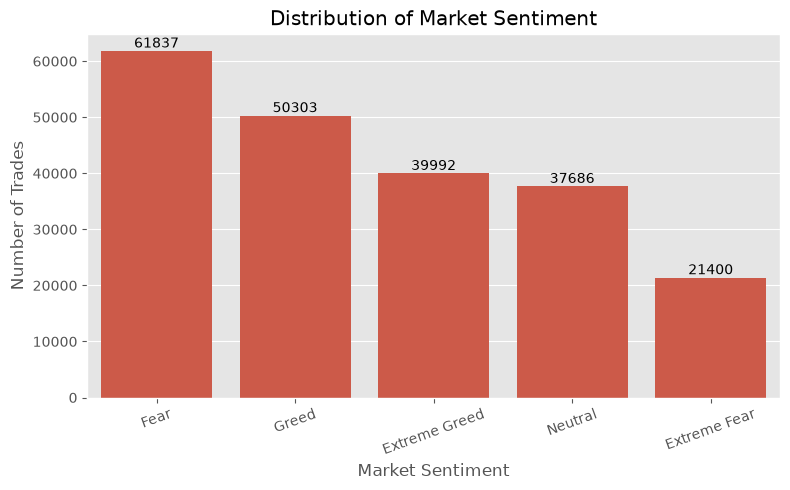

In [33]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=merged,
    x="classification",
    order=merged["classification"].value_counts().index
)

plt.title("Distribution of Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Number of Trades")
plt.xticks(rotation=20)

# Add value labels
for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.savefig("../charts/01_sentiment_distribution.png", dpi=300)
plt.show()

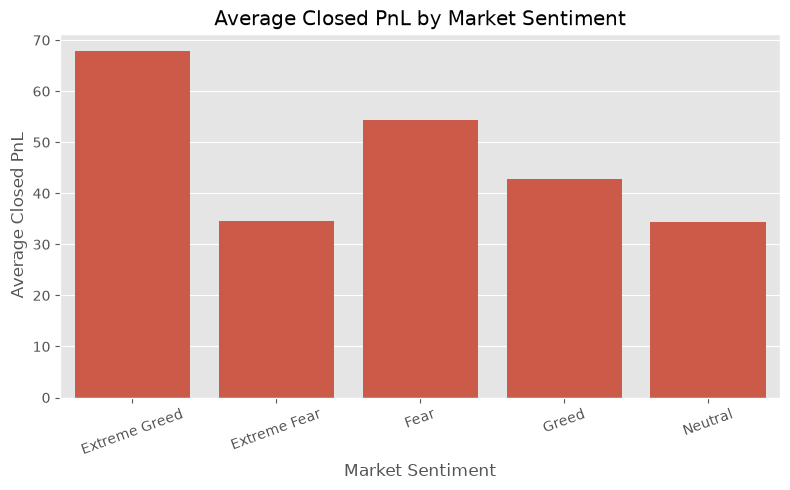

In [34]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=merged,
    x="classification",
    y="Closed PnL",
    estimator=np.mean,
    errorbar=None
)

plt.title("Average Closed PnL by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Closed PnL")

plt.xticks(rotation=20)

plt.tight_layout()
plt.savefig("../charts/02_avg_pnl.png", dpi=300)
plt.show()

Observation:

Extreme Greed records the highest average profitability (67.89), while Extreme Fear records one of the lowest values (34.54). This suggests that bullish market conditions generally provide better trading opportunities.

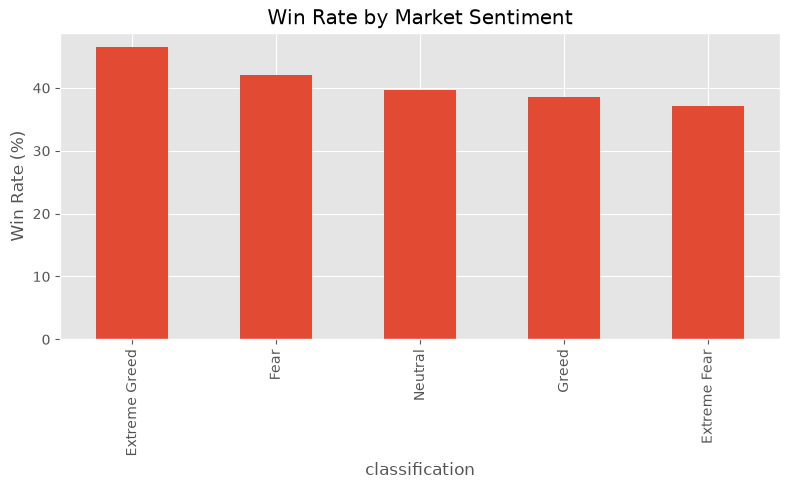

In [35]:
win_rate = (
    merged.groupby("classification")["Profit"]
    .mean()
    .sort_values(ascending=False)
    *100
)

plt.figure(figsize=(8,5))

win_rate.plot(kind="bar")

plt.title("Win Rate by Market Sentiment")
plt.ylabel("Win Rate (%)")

plt.tight_layout()
plt.savefig("../charts/03_win_rate.png", dpi=300)
plt.show()

Observation:

Trader win rate is highest during Extreme Greed (46.49%) and lowest during Extreme Fear (37.06%). Positive market sentiment appears to improve trading success.

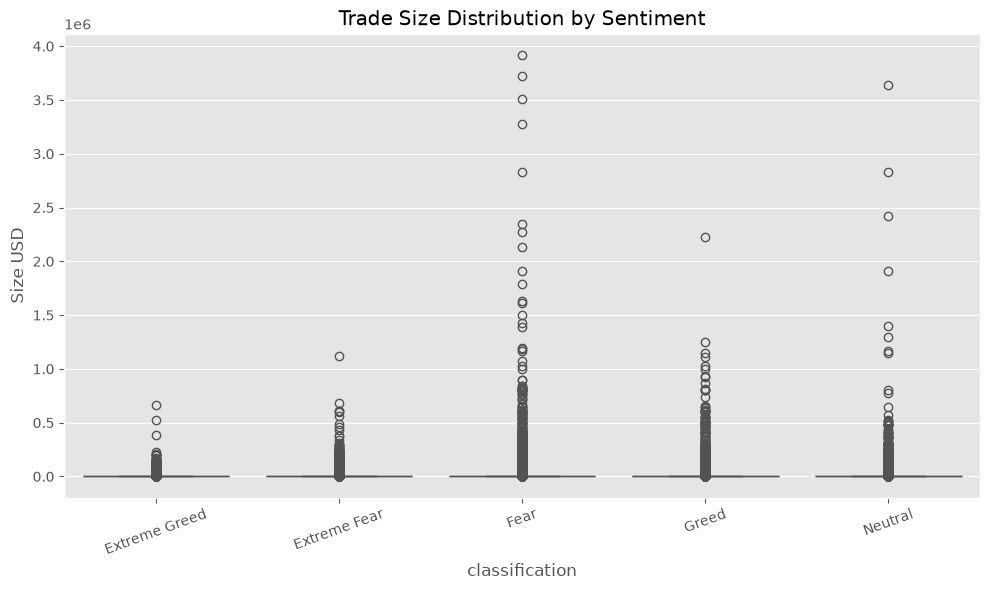

In [36]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=merged,
    x="classification",
    y="Size USD"
)

plt.title("Trade Size Distribution by Sentiment")

plt.xticks(rotation=20)

plt.tight_layout()
plt.savefig("../charts/04_trade_size.png", dpi=300)

plt.show()

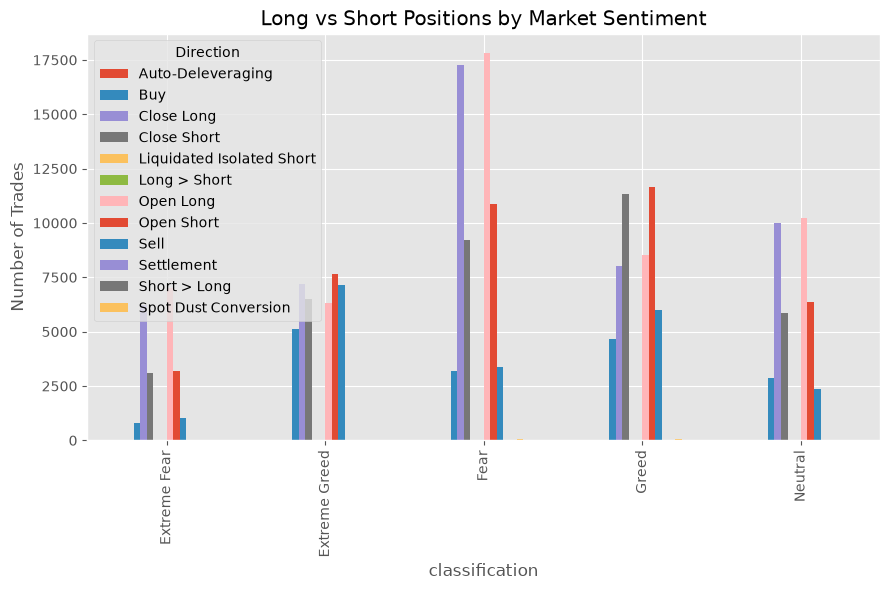

In [37]:
direction = pd.crosstab(
    merged["classification"],
    merged["Direction"]
)

direction.plot(
    kind="bar",
    figsize=(9,6)
)

plt.title("Long vs Short Positions by Market Sentiment")

plt.ylabel("Number of Trades")

plt.tight_layout()

plt.savefig("../charts/05_long_short.png", dpi=300)

plt.show()

Observation:

The distribution of Long and Short trades varies across market sentiment, indicating that traders adjust directional bias based on market conditions.

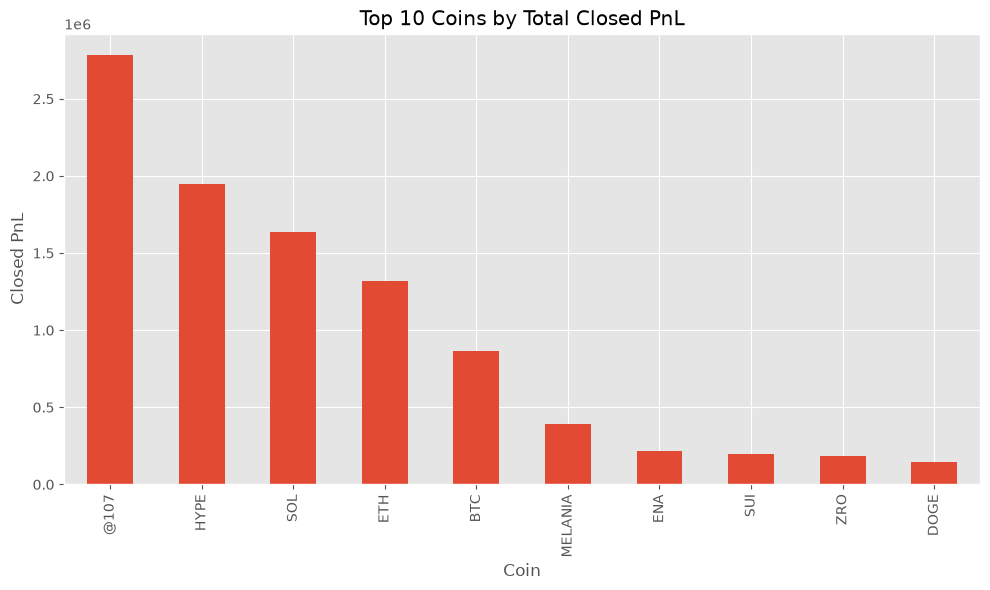

In [38]:
coin_pnl = (
    merged.groupby("Coin")["Closed PnL"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

coin_pnl.plot(kind="bar")

plt.title("Top 10 Coins by Total Closed PnL")

plt.ylabel("Closed PnL")

plt.tight_layout()

plt.savefig("../charts/06_top_coins.png", dpi=300)

plt.show()

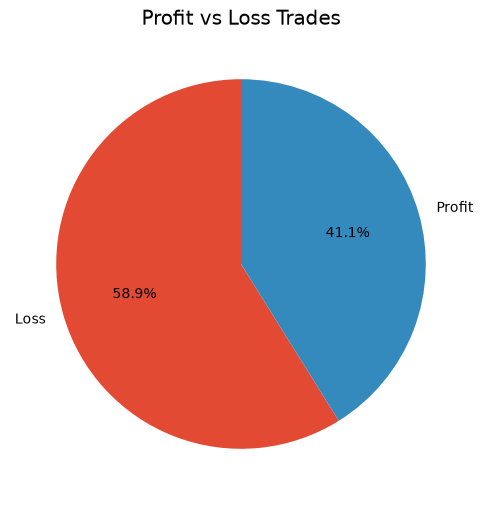

In [39]:
profit_loss = merged["Profit"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    profit_loss,
    labels=["Loss","Profit"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Profit vs Loss Trades")

plt.savefig("../charts/07_profit_loss.png", dpi=300)

plt.show()

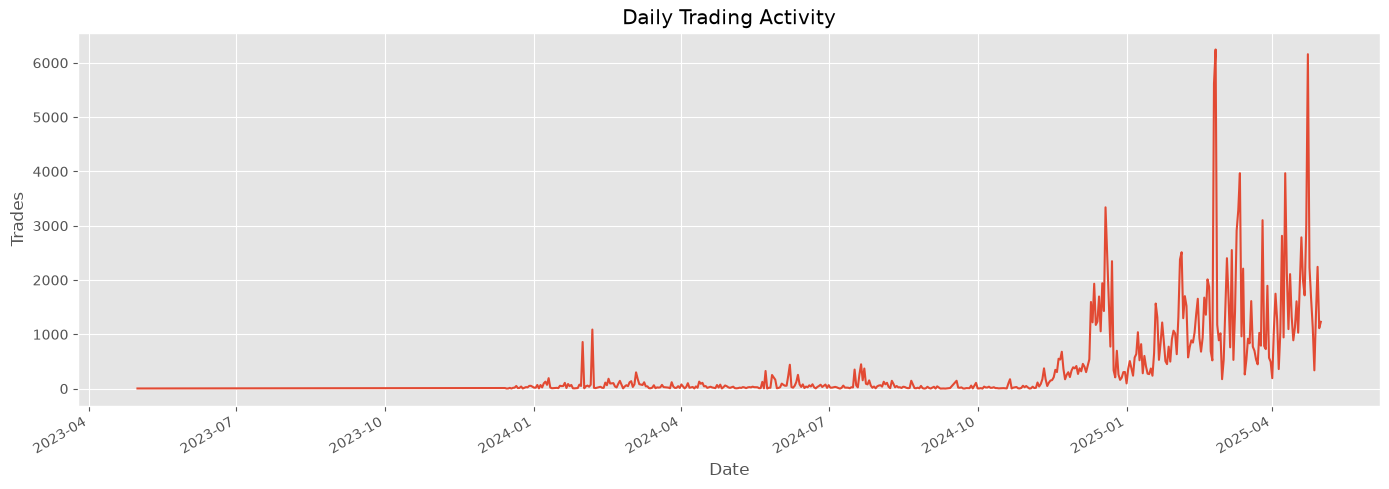

In [40]:
daily = merged.groupby("Date").size()

plt.figure(figsize=(14,5))

daily.plot()

plt.title("Daily Trading Activity")

plt.ylabel("Trades")

plt.tight_layout()

plt.savefig("../charts/08_daily_trades.png", dpi=300)

plt.show()

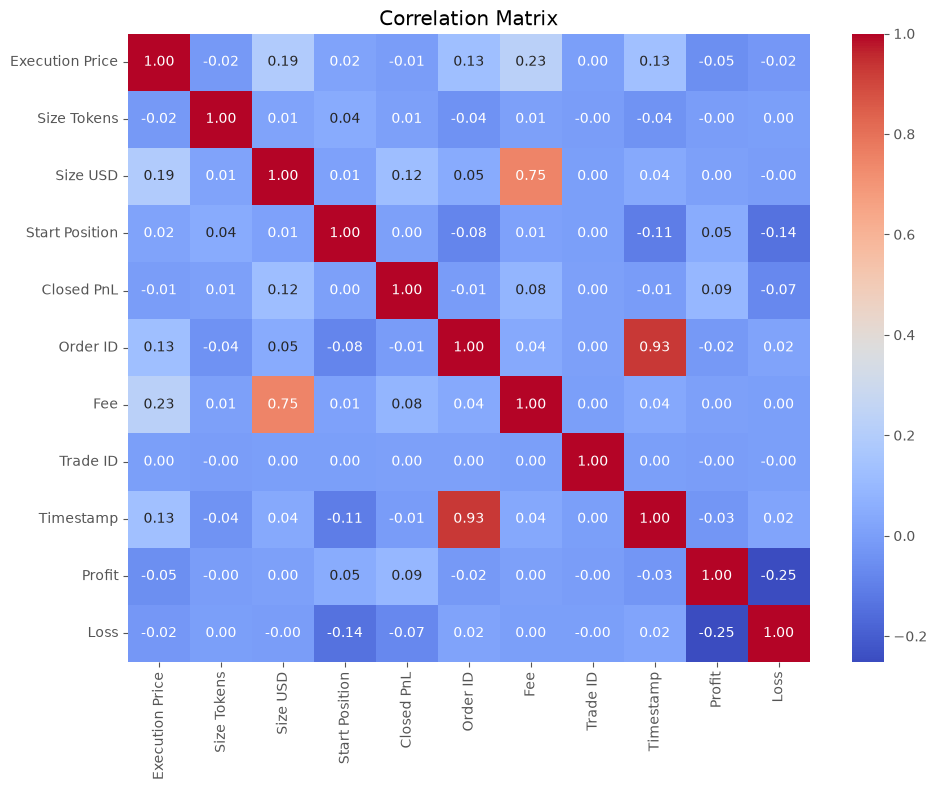

In [41]:
numeric = merged.select_dtypes(include=np.number)

plt.figure(figsize=(10,8))

sns.heatmap(
    numeric.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.tight_layout()

plt.savefig("../charts/09_heatmap.png", dpi=300)

plt.show()

In [48]:
# Create Position Category based on trade size (USD)

merged["Position Category"] = pd.qcut(
    merged["Size USD"],
    q=3,
    labels=["Small", "Medium", "Large"],
    duplicates="drop"
)

merged["Position Category"].value_counts()

Position Category
Small     70409
Large     70408
Medium    70407
Name: count, dtype: int64

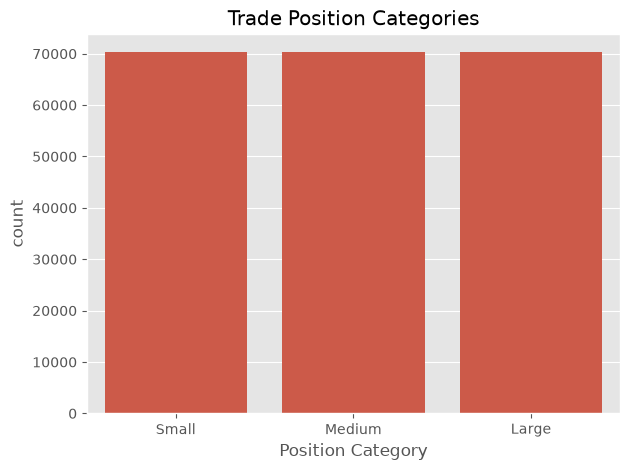

In [49]:
sns.countplot(
    data=merged,
    x="Position Category"
)

plt.title("Trade Position Categories")

plt.tight_layout()

plt.savefig("../charts/10_position_category.png", dpi=300)

plt.show()

Observation:

Position sizes change with market sentiment, suggesting traders modify their risk exposure according to market confidence.

In [43]:
merged["classification"].value_counts()

classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64

classification
Extreme Greed    46.494299
Fear             42.076750
Neutral          39.699093
Greed            38.482794
Extreme Fear     37.060748
Name: Profit, dtype: float64

classification
Extreme Fear     34.537862
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Neutral          34.307718
Name: Closed PnL, dtype: float64

# Key Insights

## Insight 1: Trading activity is highest during Fear and Greed periods.

The distribution of trades shows that the majority of trading activity occurs during **Fear (61,837 trades)** and **Greed (50,303 trades)** market conditions, while **Extreme Fear (21,400 trades)** records the lowest trading activity.

This indicates that traders remain highly active during volatile market phases rather than avoiding the market altogether.

---

## Insight 2: Traders achieve the highest profitability during Extreme Greed.

The average Closed PnL increases significantly during positive market sentiment.

| Sentiment | Average Closed PnL |
|-----------|-------------------:|
| Extreme Greed | 67.89 |
| Fear | 54.29 |
| Greed | 42.74 |
| Extreme Fear | 34.54 |
| Neutral | 34.31 |

This suggests that bullish market conditions generally provide better profit opportunities.

---

## Insight 3: Win rate is highest during Extreme Greed.

The trader win rate follows a similar trend.

| Sentiment | Win Rate (%) |
|-----------|-------------:|
| Extreme Greed | 46.49 |
| Fear | 42.08 |
| Neutral | 39.70 |
| Greed | 38.48 |
| Extreme Fear | 37.06 |

Although no sentiment produces a win rate above 50%, traders perform noticeably better during Extreme Greed than during Extreme Fear.

---

## Insight 4: Fear does not always result in the lowest profitability.

Interestingly, traders generated higher average profits during Fear (54.29) than during normal Greed (42.74).

This may indicate that experienced traders exploit market corrections by entering positions at discounted prices.

Further investigation by trader segment could validate this hypothesis.

In [ ]:
## Frequent vs Infrequent Traders
trade_frequency = (
    merged.groupby("Account")
    .size()
    .reset_index(name="Trade Count")
)

trade_frequency["Segment"] = pd.qcut(
    trade_frequency["Trade Count"],
    q=3,
    labels=["Low Frequency", "Medium Frequency", "High Frequency"]
)

trade_frequency.head()

,Account,Trade Count,Segment
0,0x083384f897ee0f19899168e3b1bec365f52a9012,3818,Medium Frequency
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,7280,High Frequency
2,0x271b280974205ca63b716753467d5a371de622ab,3809,Medium Frequency
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,13311,High Frequency
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3239,Medium Frequency


In [ ]:
##Consistent Winners
trader_pnl = (
    merged.groupby("Account")["Closed PnL"]
    .mean()
    .reset_index()
)

trader_pnl["Segment"] = pd.qcut(
    trader_pnl["Closed PnL"],
    q=3,
    labels=["Low Profit", "Medium Profit", "High Profit"]
)

trader_pnl.head()

,Account,Closed PnL,Segment
0,0x083384f897ee0f19899168e3b1bec365f52a9012,419.127768,High Profit
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,6.577654,Low Profit
2,0x271b280974205ca63b716753467d5a371de622ab,-18.492043,Low Profit
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,9.951530,Low Profit
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,52.071011,Medium Profit


# Strategy Recommendations

## Strategy 1

During **Extreme Greed** periods, traders demonstrate the highest average profitability and win rate. Traders may consider increasing participation during these periods while maintaining disciplined risk management.

---

## Strategy 2

During **Extreme Fear**, profitability and win rates decline significantly. Reducing position sizes and adopting stricter risk controls may help minimize losses during highly pessimistic market conditions.

---

## Strategy 3

Fear periods still produce relatively strong average profits compared to normal Greed, suggesting that selective buying during market corrections may provide attractive trading opportunities for experienced traders.

In [51]:
print("Summary Table")
summary = merged.groupby("classification").agg({
    "Closed PnL": "mean",
    "Profit": "mean",
    "Size USD": "mean",
    "Trade ID": "count"
})

summary.rename(columns={
    "Closed PnL": "Avg PnL",
    "Profit": "Win Rate",
    "Size USD": "Avg Trade Size",
    "Trade ID": "Trades"
}, inplace=True)

summary["Win Rate"] *= 100

summary.round(2)

Summary Table


,Avg PnL,Win Rate,Avg Trade Size,Trades
classification,,,,
Extreme Fear,34.54,37.06,5349.73,21400
Extreme Greed,67.89,46.49,3112.25,39992
Fear,54.29,42.08,7816.11,61837
Greed,42.74,38.48,5736.88,50303
Neutral,34.31,39.70,4782.73,37686


# Conclusion

This analysis demonstrates that market sentiment significantly influences trader performance and behavior.

Key findings include:

- Extreme Greed is associated with the highest profitability and win rate.
- Trading activity is concentrated during Fear and Greed periods.
- Extreme Fear corresponds to the lowest win rate, indicating increased market risk.
- Fear markets still provide profitable opportunities for disciplined traders.

These findings suggest that combining market sentiment with trader behavior can improve decision-making and risk management strategies in cryptocurrency trading.